In [19]:
import json
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

In [20]:
def load_cache(path: str | Path, duration_col: str = "duration") -> pd.DataFrame:
    with open(path, encoding="utf-8") as f:
        cache = json.load(f)

    rows = []
    for key, value in cache.items():
        row = {}
        for pair in key.split(";"):
            name, val = pair.split("=")
            row[name] = int(val)
        row[duration_col] = np.inf if value == "inf" else float(value)
        rows.append(row)

    return pd.DataFrame(rows)

In [21]:
df = load_cache('cache_64_7168_65536_single.json')
df = df[df['duration'] == df['duration'].min()]
df.head(10)

,MM_BASE_K,MM_BASE_M,MM_BASE_N,MM_CORE_NUM,MM_DB_L0A,MM_DB_L0B,MM_DB_L0C,MM_ITERATE_ORDER,MM_K,MM_M,...,MM_N,MM_N_TILE_BLOCK,MM_SINGLE_K,MM_SINGLE_M,MM_SINGLE_N,MM_STEP_Ka,MM_STEP_Kb,MM_STEP_M,MM_STEP_N,duration
96,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,2,1,3,1,1.056965e+09
119,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,4,2,3,1,1.056965e+09
120,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,1,1,3,1,1.056965e+09
142,32,64,512,20,2,2,1,1,65536,64,...,7168,8,32,64,7168,7,1,3,1,1.056965e+09
143,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,4,2,3,1,1.056965e+09
164,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,3,1,3,1,1.056965e+09
165,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,6,2,3,1,1.056965e+09
186,32,64,512,20,2,2,1,1,65536,64,...,7168,3,32,64,7168,1,3,3,1,1.056965e+09
207,32,64,512,20,2,2,1,1,65536,64,...,7168,4,32,64,7168,4,2,3,1,1.056965e+09
227,32,64,512,20,2,2,1,1,65536,64,...,7168,6,32,64,7168,6,2,3,1,1.056965e+09


<Axes: >

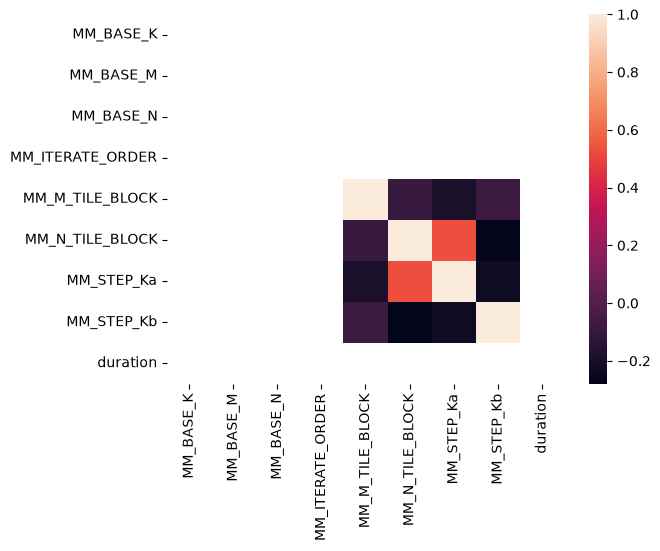

In [22]:
sns.heatmap(df.drop(columns=['MM_DB_L0A',
                             'MM_DB_L0B',
                             'MM_DB_L0C',
                             'MM_M',
                             'MM_N', 
                             'MM_K',
                             'MM_CORE_NUM',
                             'MM_SINGLE_M',
                             'MM_SINGLE_N',
                             'MM_SINGLE_K',
                             'MM_STEP_M',
                             'MM_STEP_N']).corr())

In [23]:
df[df['duration'] == df['duration'].min()]

,MM_BASE_K,MM_BASE_M,MM_BASE_N,MM_CORE_NUM,MM_DB_L0A,MM_DB_L0B,MM_DB_L0C,MM_ITERATE_ORDER,MM_K,MM_M,...,MM_N,MM_N_TILE_BLOCK,MM_SINGLE_K,MM_SINGLE_M,MM_SINGLE_N,MM_STEP_Ka,MM_STEP_Kb,MM_STEP_M,MM_STEP_N,duration
96,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,2,1,3,1,1.056965e+09
119,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,4,2,3,1,1.056965e+09
120,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,1,1,3,1,1.056965e+09
142,32,64,512,20,2,2,1,1,65536,64,...,7168,8,32,64,7168,7,1,3,1,1.056965e+09
143,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,4,2,3,1,1.056965e+09
164,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,3,1,3,1,1.056965e+09
165,32,64,512,20,2,2,1,1,65536,64,...,7168,5,32,64,7168,6,2,3,1,1.056965e+09
186,32,64,512,20,2,2,1,1,65536,64,...,7168,3,32,64,7168,1,3,3,1,1.056965e+09
207,32,64,512,20,2,2,1,1,65536,64,...,7168,4,32,64,7168,4,2,3,1,1.056965e+09
227,32,64,512,20,2,2,1,1,65536,64,...,7168,6,32,64,7168,6,2,3,1,1.056965e+09


In [24]:
df[['MM_BASE_M', 'MM_BASE_N', 'MM_BASE_K']].drop_duplicates()

,MM_BASE_M,MM_BASE_N,MM_BASE_K
96,64,512,32


In [25]:
df[(df['MM_BASE_M'] == 256) & (df['MM_BASE_N'] == 128) & (df['MM_BASE_K'] == 64)]

,MM_BASE_K,MM_BASE_M,MM_BASE_N,MM_CORE_NUM,MM_DB_L0A,MM_DB_L0B,MM_DB_L0C,MM_ITERATE_ORDER,MM_K,MM_M,...,MM_N,MM_N_TILE_BLOCK,MM_SINGLE_K,MM_SINGLE_M,MM_SINGLE_N,MM_STEP_Ka,MM_STEP_Kb,MM_STEP_M,MM_STEP_N,duration


# Base

In [26]:
data = [
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 7168, "MM_M": 2048, "MM_N": 1536,
        "MM_STEP_Ka": 4, "MM_STEP_Kb": 4, "duration": 298.420013,
        "source": "search"
    },
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 7168, "MM_M": 2048, "MM_N": 1536,
        "MM_STEP_Ka": 8, "MM_STEP_Kb": 4, "duration": 309.540009,
        "source": "baseline"
    },
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 2048, "MM_M": 2048, "MM_N": 7168,
        "MM_STEP_Ka": 4, "MM_STEP_Kb": 4, "duration": 393.299988,
        "source": "search"
    },
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 2048, "MM_M": 2048, "MM_N": 7168,
        "MM_STEP_Ka": 8, "MM_STEP_Kb": 4, "duration": 404.320007,
        "source": "baseline"
    },
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 7168, "MM_M": 4096, "MM_N": 512,
        "MM_STEP_Ka": 4, "MM_STEP_Kb": 4, "duration": 210.460007,
        "source": "search"
    },
    {
        "MM_BASE_K": 64, "MM_BASE_M": 128, "MM_BASE_N": 256,
        "MM_DB_L0A": 2, "MM_DB_L0B": 2, "MM_DB_L0C": 1,
        "MM_K": 7168, "MM_M": 4096, "MM_N": 512,
        "MM_STEP_Ka": 8, "MM_STEP_Kb": 4, "duration": 217.460007,
        "source": "baseline"
    }
]

df = pd.DataFrame(data)

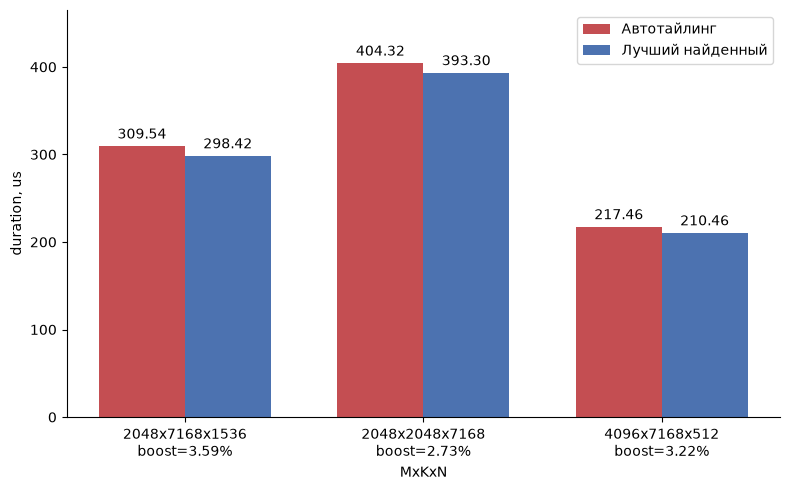

In [27]:
forms = [(2048, 1536, 7168), (2048, 7168, 2048), (4096, 512, 7168)]
def get(df) -> tuple[list, list, list]:
    base, best, diff = [], [], []
    for f in forms:
        base.append(df[(df.MM_M==f[0])&(df.MM_N==f[1])&(df.MM_K==f[2])&(df.source=="baseline")]['duration'].iloc[0])
        best.append(df[(df.MM_M==f[0])&(df.MM_N==f[1])&(df.MM_K==f[2])&(df.source=="search")]['duration'].iloc[0])
        diff.append(((base[-1] - best[-1]) / base[-1]) * 100)
    return base, best, diff

base_vals, best_vals, diff = get(df)

x = np.arange(len(forms))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Автотайлинг", color="#c44e52")
b2 = ax.bar(x + width/2, best_vals, width, label="Лучший найденный", color="#4c72b0")

ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=10)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=10)

ax.set_ylabel("duration, us")
ax.set_xticks(x)
ax.set_xticklabels([f"{M}x{K}x{N}\nboost={diff[idx]:.2f}%" for idx, (M, N, K) in enumerate(forms)])
ax.set_xlabel("MxKxN")
ax.set_ylim(0, max(base_vals)*1.15)
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results_tiling.png", dpi=130)

# Deterministic

In [30]:
data = [
    {
        "MM_K": 65536, "MM_M": 1, "MM_N": 7168,
        "duration": 896.12, "source": "search"
    },
    {
        "MM_K": 65536, "MM_M": 16, "MM_N": 7168,
        "duration": 919.06, "source": "search"
    },
    {
        "MM_K": 65536, "MM_M": 64, "MM_N": 7168,
        "duration": 943.02, "source": "search"
    },
    {
        "MM_K": 65536, "MM_M": 128, "MM_N": 7168,
        "duration": 1074.30, "source": "search"
    },
    {
        "MM_K": 65536, "MM_M": 1, "MM_N": 7168,
        "duration": 917.58, "source": "baseline"
    },
    {
        "MM_K": 65536, "MM_M": 16, "MM_N": 7168,
        "duration": 983.86, "source": "baseline"
    },
    {
        "MM_K": 65536, "MM_M": 64, "MM_N": 7168,
        "duration": 994.76, "source": "baseline"
    },
    {
        "MM_K": 65536, "MM_M": 128, "MM_N": 7168,
        "duration": 1074.3, "source": "baseline"
    },

]

df = pd.DataFrame(data)

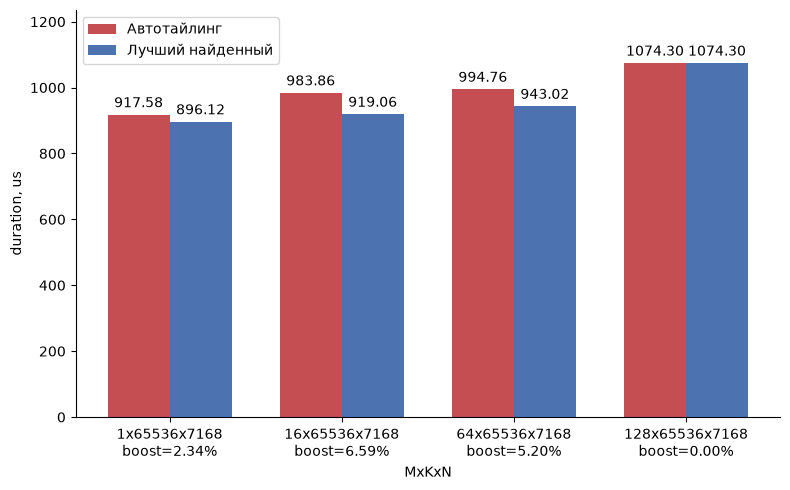

In [31]:
forms = [(1, 7168, 65536), (16, 7168, 65536), (64, 7168, 65536), (128, 7168, 65536)]
def get(df) -> tuple[list, list, list]:
    base, best, diff = [], [], []
    for f in forms:
        base.append(df[(df.MM_M==f[0])&(df.MM_N==f[1])&(df.MM_K==f[2])&(df.source=="baseline")]['duration'].iloc[0])
        best.append(df[(df.MM_M==f[0])&(df.MM_N==f[1])&(df.MM_K==f[2])&(df.source=="search")]['duration'].iloc[0])
        diff.append(((base[-1] - best[-1]) / base[-1]) * 100)
    return base, best, diff

base_vals, best_vals, diff = get(df)

x = np.arange(len(forms))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Автотайлинг", color="#c44e52")
b2 = ax.bar(x + width/2, best_vals, width, label="Лучший найденный", color="#4c72b0")

ax.bar_label(b1, fmt="%.2f", padding=3, fontsize=10)
ax.bar_label(b2, fmt="%.2f", padding=3, fontsize=10)

ax.set_ylabel("duration, us")
ax.set_xticks(x)
ax.set_xticklabels([f"{M}x{K}x{N}\nboost={diff[idx]:.2f}%" for idx, (M, N, K) in enumerate(forms)])
ax.set_xlabel("MxKxN")
ax.set_ylim(0, max(base_vals)*1.15)
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results_tiling.png", dpi=130)